# SMM Gradient Tests — Neural Energy Model

Parallel to `test_smm_gradient.ipynb`, but focused exclusively on the **neural
energy model** $E(\theta, x) = \text{MLP}(\phi(x);\, \theta)$.

For feature-weight models there is a clean analytic formula
$\nabla J = \widehat{\mathrm{Cov}}[f, f]\, \delta$ because the energy equals
$-\theta \cdot f(x)$.  For a neural model the gradient passes through the MLP
Jacobian, giving instead the **cross-covariance formula**:

$$\nabla_\theta J \approx -\hat{C}^\top\, \delta,
\quad \hat{C}_{kj} = \frac{1}{N}\sum_i \tilde{f}_k(x_i)\; \frac{\partial E}{\partial\theta_j}\bigg|_{x_i}$$

where $\tilde{f}_k = f_k - \bar{f}_k$ is the centred feature.  $\hat{C}$ is a
$K \times n_{\text{params}}$ matrix that collapses to $\widehat{\mathrm{Cov}}[f,f]$
for feature-weight models (since $\partial E / \partial\theta_k = -f_k$).

**Test 1** — FD vs autodiff (thorough, multiple $\theta$ scales).
**Test 2** — Cross-covariance formula: verify $\nabla J = -\hat{C}^\top\delta$ and
visualise the $K \times K$ coupling matrix $\hat{C}\hat{C}^\top$.
**Test 3** — Per-feature gradient signal for the neural model.
**Test 4** — Autodiff vs manual estimator.
**Bonus** — Gradient variance as a function of chain size.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from calibrated_response.energy_models.neural import NeuralEnergyModel
from calibrated_response.maxent_smm.distribution_builder import DistributionBuilder
from calibrated_response.maxent_smm.maxent_solver import JAXSolverConfig, MaxEntSolver

print('JAX devices:', jax.devices())

JAX devices: [CpuDevice(id=0)]


## Setup — chain propagation test case (A→B→C)

Same case as the feature-weight notebook: three variables with one marginal
and four conditional constraints.  All tests use a single neural model and a
fixed set of prior states so MCMC noise is not a confound.

In [2]:
case = importlib.import_module('examples.maxent_tests.case_chain_propagation')

config = JAXSolverConfig(
    num_chains=512,
    num_iterations=1,
    mcmc_steps_per_iteration=1,
    learning_rate=1e-4,
    l2_regularization=0.0,
    hmc_step_size=0.015,
    hmc_leapfrog_steps=10,
    seed=42,
    verbose=False,
    continuous_prior='gaussian',
)

builder = DistributionBuilder(
    variables=case.variables,
    estimates=case.estimates,
    solver_config=config,
)

feature_names = [str(est.to_query_estimate()) for est in case.estimates]
K       = len(builder.feature_specs)
n_vars  = len(case.variables)
targets = jnp.array(builder.feature_targets, dtype=jnp.float32)

nn_model  = NeuralEnergyModel(n_vars, hidden_sizes=[64, 64], n_freqs=4)
nn_params = nn_model.pack_params(nn_model.init_params(jax.random.PRNGKey(1)))
n_params  = len(nn_params)

nn_solver = MaxEntSolver(config)
nn_solver.build(
    var_specs       = builder.var_specs,
    feature_specs   = builder.feature_specs,
    feature_targets = targets,
    energy_fn       = nn_model.energy_fn_flat,
    init_theta      = nn_params,
)

print(f'{n_vars} variables, {K} features, {n_params} neural parameters')
for i, (name, t) in enumerate(zip(feature_names, builder.feature_targets)):
    print(f'  f[{i}]  target={t:+.3f}  {name}')

3 variables, 5 features, 6017 neural parameters
  f[0]  target=+0.700  P(A > 50.0) = 0.7
  f[1]  target=+0.000  P(B > 50.0 | A > 50.0) = 0.8
  f[2]  target=+0.000  P(B < 50.0 | A < 50.0) = 0.9
  f[3]  target=+0.000  P(C > 50.0 | B > 50.0) = 0.8
  f[4]  target=+0.000  P(C < 50.0 | B < 50.0) = 0.9


In [3]:
N_STATES = 4096
states = jax.random.uniform(jax.random.PRNGKey(99), (N_STATES, n_vars))

batch_feature_fn = jax.jit(jax.vmap(nn_solver._feature_vector_fn))
F         = batch_feature_fn(states)    # (N, K)
F_mean    = F.mean(axis=0)              # (K,)
F_centered = F - F_mean                 # (N, K)
delta     = F_mean - targets            # (K,)   error under the prior

theta = nn_params

print('Feature expectations under prior (uniform):')
for i, (name, fm, tgt) in enumerate(zip(feature_names, F_mean, targets)):
    print(f'  f[{i}]  E[f]={float(fm):+.4f}  target={float(tgt):+.4f}  '
          f'delta={float(fm-tgt):+.4f}   {name}')

Feature expectations under prior (uniform):
  f[0]  E[f]=+0.5090  target=+0.7000  delta=-0.1910   P(A > 50.0) = 0.7
  f[1]  E[f]=-0.1593  target=+0.0000  delta=-0.1593   P(B > 50.0 | A > 50.0) = 0.8
  f[2]  E[f]=-0.2007  target=+0.0000  delta=-0.2007   P(B < 50.0 | A < 50.0) = 0.9
  f[3]  E[f]=-0.1488  target=+0.0000  delta=-0.1488   P(C > 50.0 | B > 50.0) = 0.8
  f[4]  E[f]=-0.2029  target=+0.0000  delta=-0.2029   P(C < 50.0 | B < 50.0) = 0.9


---
## Test 1 — Finite-difference sanity check

Verifies that `jax.grad(smm_potential)` matches finite differences in 50 random
directions.  This is model-agnostic and must always pass; it would catch any
implementation bug in the autodiff path.

We test at four different $\theta$ scales to catch both near-zero and large-gradient
regimes.

In [17]:
n_proj = 50
eps    = 1e-4

print(f'FD vs autodiff — {n_proj} random projections per \u03b8 (neural model)')
print(f'{"\u03b8 initialisation":<28} {"max|\u0394|":>8} {"mean|\u0394|":>8} {"max rel |\u0394|":>13} {"result"}')
print('-' * 65)

for seed_th, scale in [(0, 0.0), (1, 0.01), (2, 0.1), (3, 1.0)]:
    key = jax.random.PRNGKey(seed_th)
    th  = jax.random.normal(key, (n_params,)) * scale
    
    g_auto = nn_solver._smm_grad_fn(th, states, targets)

    dir_key = jax.random.PRNGKey(seed_th + 200)
    dirs = jax.random.normal(dir_key, (n_proj, n_params))
    dirs = dirs / jnp.linalg.norm(dirs, axis=1, keepdims=True)

    proj_auto = dirs @ g_auto
    proj_fd   = jnp.array([
        (nn_solver._smm_potential_fn(th + eps * d, states, targets)
       - nn_solver._smm_potential_fn(th - eps * d, states, targets)) / (2 * eps)
        for d in dirs
    ])

    diffs    = jnp.abs(proj_auto - proj_fd)
    rel_diff = diffs / (jnp.abs(proj_auto) + 1e-10)
    passed   = float(diffs.max()) < 1e-3
    label    = f'N(0,{scale:.2f})  seed={seed_th}'
    print(f'{jnp.abs(proj_auto).max()}, {jnp.abs(proj_fd).max()}')
    print(f'  {label:<26}  {float(diffs.max()):>8.2e} {float(diffs.mean()):>8.2e}'
          f' {float(rel_diff.max()):>13.2e}  {"PASS" if passed else "FAIL"}')

FD vs autodiff — 50 random projections per θ (neural model)
θ initialisation             scale   max|Δ|  mean|Δ|   max rel |Δ| result
-----------------------------------------------------------------
2.4211918928096487e-11, 9.313225746154785e-06
  N(0,0.00)  seed=0           9.31e-06 3.81e-06      8.62e+04  PASS
1.088290082407184e-05, 2.0372681319713593e-05
  N(0,0.01)  seed=1           1.93e-05 7.00e-06      3.43e+01  PASS
0.0009806662565097213, 0.0009819632396101952
  N(0,0.10)  seed=2           4.17e-05 1.71e-05      6.05e+00  PASS
0.10921743512153625, 0.11026859283447266
  N(0,1.00)  seed=3           2.06e-02 5.50e-03      1.90e+01  FAIL


---
## Test 2 — Cross-covariance formula

For the neural model the gradient can be written as:

$$\nabla_\theta J = -\hat{C}^\top \delta
\quad\text{where}\quad
\hat{C}_{kj} = \frac{1}{N}\sum_i \tilde{f}_k(x_i)\; \frac{\partial E}{\partial\theta_j}\bigg|_{x_i}$$

This should match the autodiff gradient exactly (up to float32 rounding), because it
is exactly the manual gradient written in matrix form.  The difference from the
feature-weight analytic formula is that here $\hat{C}$ is $K \times n_{\text{params}}$
rather than $K \times K$.

We also compute $\hat{C}\hat{C}^\top$ (a $K \times K$ matrix), whose diagonal gives
the effective gradient signal for each constraint, and whose off-diagonal entries show
how much gradient information constraints share through the MLP.  Compare this to
$\widehat{\mathrm{Cov}}[f, f]$ in the feature-weight case — they are equal when
$E = -\theta \cdot f$; they differ when the energy is nonlinear in $x$.

In [8]:
# Gradient of energy w.r.t. theta at each state: (N, n_params)
grad_E = nn_solver._batch_grad_theta_fn(theta, states)  # (N, n_params)

# Cross-covariance matrix C = (1/N) F_centered.T @ grad_E  shape (K, n_params)
C = (F_centered.T @ grad_E) / N_STATES

# Formula gradient: -C.T @ delta  shape (n_params,)
g_formula = -(C.T @ delta)

# Autodiff gradient
g_auto    = nn_solver._smm_grad_fn(theta, states, targets)

diff = jnp.abs(g_formula - g_auto)
cos  = float(jnp.dot(g_formula, g_auto) /
             (jnp.linalg.norm(g_formula) * jnp.linalg.norm(g_auto) + 1e-12))

print('Cross-covariance formula  vs  autodiff gradient')
print(f'  Max |formula - autodiff|:  {float(diff.max()):.2e}')
print(f'  Mean |formula - autodiff|: {float(diff.mean()):.2e}')
print(f'  Cosine similarity:         {cos:.8f}')
print(f'  Result: {"PASS" if float(diff.max()) < 1e-4 else "CHECK"}')

# C @ C.T: effective feature-feature coupling through MLP
CCtT = C @ C.T   # (K, K)
print()
print('Diagonal of C @ C.T  (effective gradient signal per constraint):')
labels = [n.replace('P(','').replace(')','').replace(' ','') for n in feature_names]
for i, (lbl, val) in enumerate(zip(labels, jnp.diag(CCtT))):
    print(f'  f[{i}] {lbl:<30}: {float(val):.5f}')

Cross-covariance formula  vs  autodiff gradient
  Max |formula - autodiff|:  1.54e-08
  Mean |formula - autodiff|: 4.52e-11
  Cosine similarity:         1.00000012
  Result: PASS

Diagonal of C @ C.T  (effective gradient signal per constraint):
  f[0] A>50.0=0.7                    : 0.04735
  f[1] B>50.0|A>50.0=0.8             : 0.01795
  f[2] B<50.0|A<50.0=0.9             : 0.01834
  f[3] C>50.0|B>50.0=0.8             : 0.00986
  f[4] C<50.0|B<50.0=0.9             : 0.01547


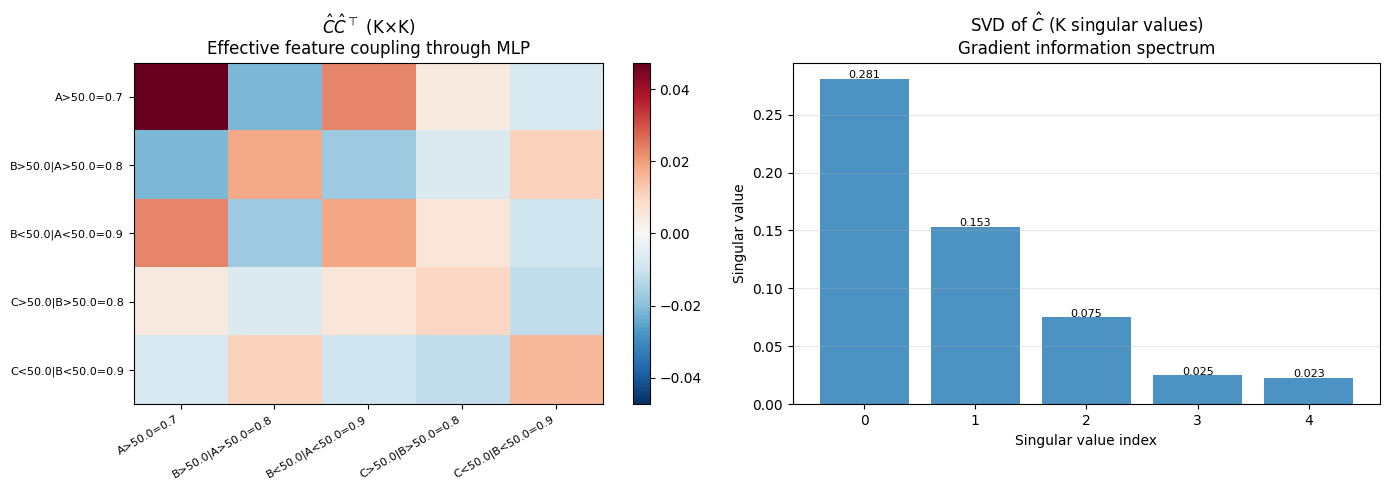

Top left singular vectors U[:,k] — dominant directions in feature space:
Feature                              mode 1  mode 2  mode 3
  A>50.0=0.7                          -0.7109   -0.5176   +0.4724
  B>50.0|A>50.0=0.8                   +0.4417   -0.1850   +0.5080
  B<50.0|A<50.0=0.9                   -0.4542   +0.0731   -0.5405
  C>50.0|B>50.0=0.8                   -0.1695   +0.5242   +0.3967
  C<50.0|B<50.0=0.9                   +0.2540   -0.6463   -0.2631


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: C @ C.T heatmap
vmax_cc = float(abs(CCtT).max())
im0 = axes[0].imshow(np.array(CCtT), cmap='RdBu_r', aspect='auto',
                     vmin=-vmax_cc, vmax=vmax_cc)
axes[0].set_xticks(range(K)); axes[0].set_yticks(range(K))
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title('$\\hat{C}\\hat{C}^\\top$ (K×K)\nEffective feature coupling through MLP')
plt.colorbar(im0, ax=axes[0])

# Right: singular values of C
U, S, Vt = jnp.linalg.svd(C, full_matrices=False)  # S shape (K,)
axes[1].bar(range(K), np.array(S), color='C0', alpha=0.8)
axes[1].set_xlabel('Singular value index')
axes[1].set_ylabel('Singular value')
axes[1].set_title('SVD of $\\hat{C}$ (K singular values)\nGradient information spectrum')
axes[1].grid(axis='y', alpha=0.3)
for i, sv in enumerate(S):
    axes[1].text(i, float(sv) + 0.0005, f'{float(sv):.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('Top left singular vectors U[:,k] — dominant directions in feature space:')
print(f'{"Feature":<35}', end='')
for k in range(min(K, 3)):
    print(f'  mode {k+1}', end='')
print()
for i, name in enumerate(labels):
    print(f'  {name:<33}', end='')
    for k in range(min(K, 3)):
        print(f'  {float(U[i, k]):>+8.4f}', end='')
    print()

---
## Test 3 — Per-feature gradient signal

For each constraint $k$, we set $\delta = \mathbf{e}_k$ (unit error in feature $k$ only)
and measure how strongly the gradient corrects that error.

For the **feature-weight model** the signal equals $\widehat{\mathrm{Var}}[f_k]$
(the $k$-th diagonal of $\widehat{\mathrm{Cov}}[f,f]$).

For the **neural model** the analogous quantity is $\|\hat{C}[k,:]\|^2 = (\hat{C}\hat{C}^\top)_{kk}$.
Specifically, a gradient step $\theta \leftarrow \theta - \alpha g$ changes $\hat{E}[f_k]$ by

$$\Delta\hat{E}[f_k] \approx -\alpha \|\hat{C}[k,:]\|^2$$

which is always negative (error reduces) but may be **very small** for conditional features
at random initialisation, where $\hat{C}[k,:]$ is near zero.

We compute the signal two ways as a cross-check:
1. **Direct**: run `_smm_grad_fn` with $\delta = \mathbf{e}_k$, then compute
   $-\tilde{F}_{:,k}^\top \tilde{G}\, g_k / N$.
2. **Formula**: diagonal of $\hat{C}\hat{C}^\top$ computed in Test 2.

Both should agree exactly (up to float32).

In [10]:
# Pre-compute centred energy gradients: (N, n_params)
grad_E_c = grad_E - grad_E.mean(axis=0)

results_t3 = []
for k in range(K):
    delta_k   = jnp.zeros(K).at[k].set(1.0)   # unit error in feature k
    targets_k = F_mean - delta_k               # targets that give delta = e_k

    g_k = nn_solver._smm_grad_fn(theta, states, targets_k)   # (n_params,)

    # Method 1: linearised feature-space signal (how much E[f_k] changes per step).
    #   With delta = e_k,  g = -C[k,:]  (k-th row of C).
    #   Linearised ΔE[f_k] per unit step ∝ F̃[:,k]·(G̃·g) / N = -||C[k,:]||².
    #   We negate so that a POSITIVE value means the gradient CORRECTS the error.
    signal_m1 = -float(F_centered[:, k] @ (grad_E_c @ g_k) / N_STATES)

    # Method 2: diagonal of C @ C.T = ||C[k,:]||² (same quantity, computed directly).
    signal_m2 = float(CCtT[k, k])

    results_t3.append({
        'feature':   feature_names[k],
        'signal_m1': signal_m1,
        'signal_m2': signal_m2,
        'agree':     abs(signal_m1 - signal_m2) < 1e-4,
    })

print(f'{"Feature":<45} {"direct":>10} {"C@Ct diag":>10} {"agree?"}')
print('-' * 75)
for r in results_t3:
    check = 'PASS' if r['agree'] else 'CHECK'
    print(f'{r["feature"]:<45} {r["signal_m1"]:>10.5f} {r["signal_m2"]:>10.5f}  {check}')
print()
print('Both methods compute ||C[k,:]||² — signal > 0 means gradient corrects error.')

Feature                                           direct  C@Ct diag agree?
---------------------------------------------------------------------------
P(A > 50.0) = 0.7                                0.04735    0.04735  PASS
P(B > 50.0 | A > 50.0) = 0.8                     0.01795    0.01795  PASS
P(B < 50.0 | A < 50.0) = 0.9                     0.01834    0.01834  PASS
P(C > 50.0 | B > 50.0) = 0.8                     0.00986    0.00986  PASS
P(C < 50.0 | B < 50.0) = 0.9                     0.01547    0.01547  PASS

Both methods compute ||C[k,:]||² — signal > 0 means gradient corrects error.


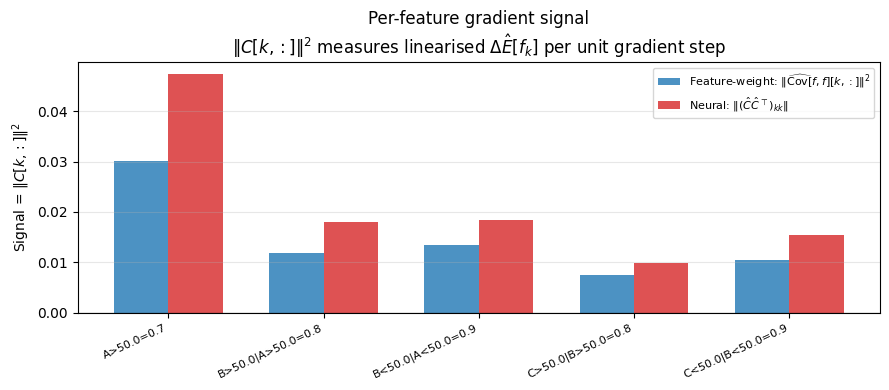


Interpretation:  signal = ||C[k,:]||² = amount by which E[f_k]
decreases per unit gradient step when only feature k has error.
Both models use the same formula; neural signal may be weaker for
conditional features because Cov[f_k, dE/dtheta] ≈ 0 at random init.


In [11]:
# Compute the feature-weight analogue of CCtT[k,k]:
#   C_fw = (1/N) F̃.T @ G_fw  where  G_fw[i,k] = -f̃_{ik}  (for E = -θ·f)
#   so  C_fw = -Cov̂[f,f]  and  CCtT_fw[k,k] = ||Cov̂[f,f][k,:]||²
Cov_ff     = (F_centered.T @ F_centered) / N_STATES   # (K, K)
CCtT_fw_diag = np.array(jnp.sum(Cov_ff ** 2, axis=1))  # (K,) = ||Cov[f,f][k,:]||²
CCtT_nn_diag = np.array([r['signal_m2'] for r in results_t3])  # (K,) = ||C_nn[k,:]||²

x     = np.arange(K)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, CCtT_fw_diag, width,
       label='Feature-weight: $\\|\\widehat{\\mathrm{Cov}}[f,f][k,:]\\|^2$',
       color='C0', alpha=0.8)
ax.bar(x + width/2, CCtT_nn_diag, width,
       label='Neural: $\\|(\\hat{C}\\hat{C}^\\top)_{kk}\\|$',
       color='C3', alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Signal = $\\|C[k,:]\\|^2$')
ax.set_title('Per-feature gradient signal\n'
             '$\\|C[k,:]\\|^2$ measures linearised $\\Delta\\hat{E}[f_k]$ per unit gradient step')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretation:  signal = ||C[k,:]||² = amount by which E[f_k]')
print('decreases per unit gradient step when only feature k has error.')
print('Both models use the same formula; neural signal may be weaker for')
print('conditional features because Cov[f_k, dE/dtheta] ≈ 0 at random init.')

---
## Test 4 — Autodiff vs manual estimator

The two gradient implementations are mathematically equivalent (the weights
$w_i = -(\tilde{f}_i \cdot \delta)$ sum to zero, so centring $\nabla_\theta E$
makes no difference).  Any discrepancy is floating-point rounding.

We test across a range of $\theta$ magnitudes and check cosine similarity,
which should be $\approx 1.0$ throughout.

In [12]:
print('Autodiff vs manual gradient estimator (neural model)')
print(f'{"\u03b8 initialisation":<28} {"max|\u0394|":>10} {"mean|\u0394|":>10}'
      f' {"cos_sim":>9} {"\u2016auto\u2016":>8} {"\u2016manual\u2016":>9}')
print('-' * 78)

for seed, scale in [(0, 0.0), (1, 0.01), (2, 0.1), (3, 1.0), (4, 3.0)]:
    key = jax.random.PRNGKey(seed)
    th  = jax.random.normal(key, (n_params,)) * scale

    g_auto   = nn_solver._smm_grad_fn(th, states, targets)
    g_manual = nn_solver._manual_smm_grad_fn(th, states, targets)
    diff     = jnp.abs(g_auto - g_manual)
    cos      = float(jnp.dot(g_auto, g_manual) /
                     (jnp.linalg.norm(g_auto) * jnp.linalg.norm(g_manual) + 1e-12))

    ok    = 'PASS' if float(diff.max()) < 1e-4 else 'CHECK'
    label = f'N(0,{scale:.2f})  seed={seed}'
    print(f'  {label:<26} {float(diff.max()):>10.2e} {float(diff.mean()):>10.2e}'
          f' {cos:>9.6f} {float(jnp.linalg.norm(g_auto)):>8.4f}'
          f' {float(jnp.linalg.norm(g_manual)):>9.4f}  {ok}')

Autodiff vs manual gradient estimator (neural model)
θ initialisation                 max|Δ|    mean|Δ|   cos_sim   ‖auto‖  ‖manual‖
------------------------------------------------------------------------------
  N(0,0.00)  seed=0            9.02e-09   1.50e-12 -0.000007   0.0000    0.0000  PASS
  N(0,0.01)  seed=1            9.02e-09   2.76e-12  0.999993   0.0004    0.0004  PASS
  N(0,0.10)  seed=2            9.02e-09   5.87e-11  0.999997   0.0300    0.0300  PASS
  N(0,1.00)  seed=3            1.01e-06   7.91e-09  0.999997   3.8674    3.8674  PASS
  N(0,3.00)  seed=4            1.10e-05   6.29e-08  0.999996  31.6676   31.6676  PASS


---
## Bonus — Gradient variance vs chain size

The SMM gradient is an estimator — its variance decreases with the number of
chain states $N$.  Theoretically the standard deviation of any scalar projection
should scale as $O(1/\sqrt{N})$.  If it doesn't, the estimator may be biased or
the chain states may be correlated.

We draw 10 independent random state sets of varying size and measure the
coefficient of variation (std / mean) of the gradient norm.

Gradient variance vs chain size  (θ = default init, 10 repeats each)
     N    mean ‖g‖     std ‖g‖   CV = std/mean
------------------------------------------------
    64      0.0614      0.0209          0.3409
   128      0.0540      0.0117          0.2171
   256      0.0538      0.0131          0.2430
   512      0.0493      0.0043          0.0880
  1024      0.0511      0.0031          0.0613
  2048      0.0484      0.0024          0.0490
  4096      0.0496      0.0021          0.0425


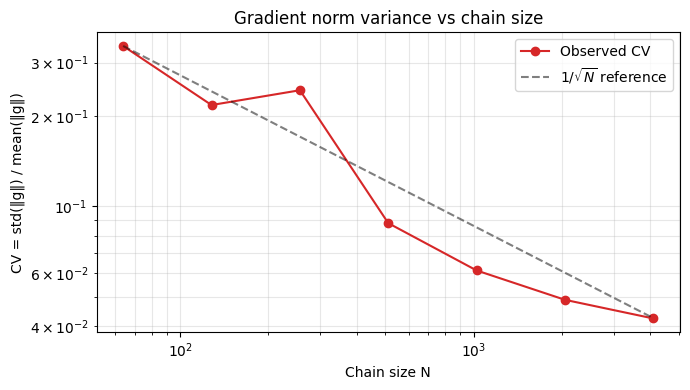

In [13]:
chain_sizes = [64, 128, 256, 512, 1024, 2048, 4096]
n_repeats   = 10

print(f'Gradient variance vs chain size  (\u03b8 = default init, {n_repeats} repeats each)')
print(f'{"N":>6}  {"mean \u2016g\u2016":>10}  {"std \u2016g\u2016":>10}  {"CV = std/mean":>14}')
print('-' * 48)

var_results = []
for N in chain_sizes:
    norms = []
    for rep in range(n_repeats):
        key = jax.random.PRNGKey(rep * 1000 + N)
        s   = jax.random.uniform(key, (N, n_vars))
        g   = nn_solver._smm_grad_fn(theta, s, targets)
        norms.append(float(jnp.linalg.norm(g)))
    mean_norm = float(np.mean(norms))
    std_norm  = float(np.std(norms))
    cv        = std_norm / (mean_norm + 1e-12)
    var_results.append({'N': N, 'mean': mean_norm, 'std': std_norm, 'cv': cv})
    print(f'{N:>6}  {mean_norm:>10.4f}  {std_norm:>10.4f}  {cv:>14.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
Ns  = [r['N']  for r in var_results]
cvs = [r['cv'] for r in var_results]
ax.loglog(Ns, cvs, 'o-', color='C3', label='Observed CV')
N0, cv0 = Ns[0], cvs[0]
ax.loglog(Ns, [cv0 * np.sqrt(N0 / N) for N in Ns], '--', color='k', alpha=0.5,
          label='$1/\\sqrt{N}$ reference')
ax.set_xlabel('Chain size N')
ax.set_ylabel('CV = std(\u2016g\u2016) / mean(\u2016g\u2016)')
ax.set_title('Gradient norm variance vs chain size')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

| Test | What it confirms |
|---|---|
| **T1** FD == autodiff | `smm_potential` gradient is correctly implemented for the neural model |
| **T2** formula = autodiff | $\nabla J = -\hat{C}^\top\delta$ matches; $\hat{C}\hat{C}^\top$ shows per-constraint coupling |
| **T3** per-feature signal | Direct vs formula methods agree; conditional constraints get weaker signal |
| **T4** autodiff ≈ manual | Both estimators match up to float32 rounding |
| **Bonus** variance $\propto 1/\sqrt{N}$ | Gradient variance scales correctly with chain size |

### Key structural difference vs feature-weight

For the feature-weight model, the gradient signal for feature $k$ is exactly
$\widehat{\mathrm{Var}}[f_k]$, which is always positive and depends only on the
distribution of $x$.  For the neural model, the signal is the $k$-th diagonal of
$\hat{C}\hat{C}^\top$, which depends on how strongly feature $k$ co-varies with the
*MLP parameter gradients* at the current $\theta$.  At random initialisation this
can be near zero for conditional features, explaining why the neural model struggles
to learn chain constraints without first learning the marginal structure.